# Room occupancy estimation: my re-analysis

In this notebook I re-run my first analysis (`occupancy_test.ipynb`) from top to bottom and then go deeper.
Every number and figure in my paper (`paper/`) comes from here.

What I do:
- **A.** Reproduce my original results
- **B.** Audit the data for patterns I missed the first time
- **C.** Rebuild my features so they don't run across recording gaps, and add new ones
- **D.** Compare 17 models and rules, holding out one day at a time
- **E.** Check where the errors happen and how the room-release rule really behaves
- **F.** Stress-test the models: a person sitting still, and losing a sensor
- **G.** Check what the models actually rely on (permutation importance)
- **H.** Try head-count estimation (0-3 people) and see how optimistic a random split is

In [1]:
import json, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (confusion_matrix, f1_score, recall_score, accuracy_score,
                             average_precision_score, brier_score_loss)
import lightgbm as lgb
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)

DATA = '../Occupancy_Estimation.csv'
FIG = '../paper/figures/'
RESULTS = {}

# plot style: same colours and fonts in every figure
C_BLUE, C_ORANGE, C_AQUA, C_RED = '#2a78d6', '#eb6834', '#1baf7a', '#e34948'
INK, INK2, GRID = '#0b0b0b', '#52514e', '#e6e5e0'
plt.rcParams.update({'font.size': 9, 'axes.edgecolor': INK2, 'axes.labelcolor': INK2,
                     'xtick.color': INK2, 'ytick.color': INK2, 'axes.grid': True, 'grid.color': GRID,
                     'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titlesize': 10, 'axes.titleweight': 'bold', 'axes.titlecolor': INK,
                     'lines.linewidth': 2, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
                     'figure.facecolor': 'white'})

## A. Reproducing my original results
Same steps as in `occupancy_test.ipynb`, in order, so I can check I get the same numbers.

In [2]:
raw = pd.read_csv(DATA)
raw['Datetime'] = pd.to_datetime(raw['Date'] + ' ' + raw['Time'], format='%Y/%m/%d %H:%M:%S')
raw = raw.drop(columns=['Date', 'Time']).sort_values('Datetime').reset_index(drop=True)
raw['occupied'] = (raw['Room_Occupancy_Count'] > 0).astype(int)
raw['day'] = raw['Datetime'].dt.date.astype(str)

o = raw.copy()   # my original features, exactly as in occupancy_test.ipynb
o['S6_PIR_5min'] = o['S6_PIR'].rolling(10, min_periods=1).max()
o['S7_PIR_5min'] = o['S7_PIR'].rolling(10, min_periods=1).max()
motion = o[['S6_PIR', 'S7_PIR']].max(axis=1)
groups = (motion == 1).cumsum()
o['time_since_motion'] = groups.groupby(groups).cumcount()

TEMP  = ['S1_Temp', 'S2_Temp', 'S3_Temp', 'S4_Temp']
LIGHT = ['S1_Light', 'S2_Light', 'S3_Light', 'S4_Light']
SOUND = ['S1_Sound', 'S2_Sound', 'S3_Sound', 'S4_Sound']
ORIG_BASE = TEMP + LIGHT + SOUND + ['S5_CO2', 'S5_CO2_Slope', 'S6_PIR_5min', 'S7_PIR_5min']
ORIG_V2 = ORIG_BASE + ['time_since_motion']
ORIG_NL = [c for c in ORIG_V2 if c not in LIGHT]

train, test = o[o.Datetime < '2018-01-10'], o[o.Datetime >= '2018-01-10']
def cm(m, cols):
    m.fit(train[cols], train.occupied)
    return m, m.predict(test[cols]), confusion_matrix(test.occupied, m.predict(test[cols])).ravel()

rows = []
for name, m, cols in [
    ('LR baseline',                   LogisticRegression(max_iter=1000), ORIG_BASE),
    ('LR balanced',                   LogisticRegression(max_iter=1000, class_weight='balanced'), ORIG_BASE),
    ('LR balanced + time_since_motion', LogisticRegression(max_iter=1000, class_weight='balanced'), ORIG_V2),
    ('LR no light (final model)',     LogisticRegression(max_iter=1000, class_weight='balanced'), ORIG_NL),
    ('RF 100 trees no light',         RandomForestClassifier(100, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_NL),
    ('RF 1000 trees no light',        RandomForestClassifier(1000, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_NL),
    ('RF WITH light (not tried originally)', RandomForestClassifier(500, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_V2)]:
    fitted, pred, (tn, fp, fn, tp) = cm(m, cols)
    rows.append(dict(model=name, TN=tn, FP=fp, FN=fn, TP=tp, recall=round(tp/(tp+fn), 3)))
    if name.startswith('LR balanced +'): pred_light = pred
    if name.startswith('LR no light'): lr_final, pred_final = fitted, pred
repro = pd.DataFrame(rows); RESULTS['reproduction'] = repro.to_dict('records'); repro

,model,TN,FP,FN,TP,recall
0,LR baseline,1751,0,184,110,0.374
1,LR balanced,1751,0,184,110,0.374
2,LR balanced + time_since_motion,1751,0,184,110,0.374
3,LR no light (final model),1738,13,0,294,1.000
4,RF 100 trees no light,1740,11,0,294,1.000
5,RF 1000 trees no light,1740,11,0,294,1.000
6,RF WITH light (not tried originally),1751,0,184,110,0.374


In [3]:
# things I wrote in my notes but never actually computed in the first notebook
miss = test[(test.occupied == 1) & (pred_light == 0)]
fpr  = test[(test.occupied == 0) & (pred_final == 1)]
tr_cm = confusion_matrix(train.occupied, lr_final.predict(train[ORIG_NL])).ravel()
print('184 misses:', len(miss), miss.Datetime.min(), '->', miss.Datetime.max(), '| median S1/S2 light', miss.S1_Light.median(), miss.S2_Light.median())
print('13 false alarms:', len(fpr), fpr.Datetime.min(), '->', fpr.Datetime.max(), '| last occupied snapshot', test[test.occupied==1].Datetime.max())
print('final LR on its own training days (TN, FP, FN, TP):', tr_cm)
print('final LR coefficients:', dict(zip(ORIG_NL, lr_final.coef_[0].round(2))))
print('S1_Light >= 50 alone misclassifies', int(((train.S1_Light >= 50).astype(int) != train.occupied).sum()), 'of', len(train), 'training rows')

184 misses: 184 2018-01-10 15:25:48 -> 2018-01-10 17:00:15 | median S1/S2 light 7.0 7.0
13 false alarms: 13 2018-01-10 17:57:27 -> 2018-01-10 18:04:05 | last occupied snapshot 2018-01-10 17:56:56
final LR on its own training days (TN, FP, FN, TP): [6359  118    1 1606]
final LR coefficients: {'S1_Temp': np.float64(4.91), 'S2_Temp': np.float64(-0.48), 'S3_Temp': np.float64(-2.04), 'S4_Temp': np.float64(-2.22), 'S1_Sound': np.float64(2.68), 'S2_Sound': np.float64(-0.05), 'S3_Sound': np.float64(0.5), 'S4_Sound': np.float64(0.01), 'S5_CO2': np.float64(-0.0), 'S5_CO2_Slope': np.float64(0.55), 'S6_PIR_5min': np.float64(-0.0), 'S7_PIR_5min': np.float64(-0.55), 'time_since_motion': np.float64(-0.39)}
S1_Light >= 50 alone misclassifies 3 of 8084 training rows


## B. Data audit
Looking for patterns I missed the first time.

In [4]:
gap_min = raw.Datetime.diff().dt.total_seconds() / 60
print('median spacing (s):', raw.Datetime.diff().dt.total_seconds().median())
print('gaps > 5 min:'); print(raw.loc[gap_min > 5, ['Datetime']].assign(gap_minutes=gap_min[gap_min > 5].round(1)).to_string())

ep = (raw.occupied.diff() != 0).cumsum()
episodes = raw.groupby(ep).agg(start=('Datetime', 'first'), end=('Datetime', 'last'),
                               occupied=('occupied', 'first'), snapshots=('occupied', 'size'),
                               max_people=('Room_Occupancy_Count', 'max'))
episodes = episodes[episodes.occupied == 1].reset_index(drop=True)
RESULTS['occupied_episodes'] = len(episodes); episodes

median spacing (s): 31.0
gaps > 5 min:
                Datetime  gap_minutes
216  2017-12-22 13:08:03         25.5
5305 2017-12-25 09:11:42       1440.9
8084 2018-01-10 15:25:48      21975.8


,start,end,occupied,snapshots,max_people
0,2017-12-22 10:49:41,2017-12-22 14:15:27,1,346,3
1,2017-12-22 15:25:24,2017-12-22 19:36:36,1,479,3
2,2017-12-23 11:49:16,2017-12-23 14:09:40,1,272,2
3,2017-12-23 15:26:46,2017-12-23 19:51:46,1,510,3
4,2018-01-10 15:25:48,2018-01-10 17:56:56,1,294,3


In [5]:
# does S5_CO2_Slope use future readings? I compare it with backward and centred least-squares slopes
def ls_slope(s, w, center):
    x = np.arange(w) - (w - 1) / 2
    return s.rolling(w, center=center).apply(lambda v: np.dot(x, v) / np.dot(x, x), raw=True)
co2 = raw.S5_CO2.astype(float)
slope_check = pd.DataFrame({w: {'trailing': raw.S5_CO2_Slope.corr(ls_slope(co2, w, False)),
                                'centred':  raw.S5_CO2_Slope.corr(ls_slope(co2, w, True))}
                            for w in [11, 21, 25, 31, 41]}).T.round(4)
RESULTS['co2_slope_trailing25_corr'] = float(slope_check.loc[25, 'trailing']); slope_check

,trailing,centred
11,0.8170,0.6764
21,0.9861,0.7921
25,1.0000,0.8212
31,0.9821,0.8549
41,0.9355,0.8905


In [6]:
# light looks like desk lamps (S1 on with 1 person, S2/S3 with 2-3), plus daylight on empty days
print(raw.groupby('Room_Occupancy_Count')[LIGHT + ['S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR']].mean().round(2).T)
print('empty snapshots with S1 or S2 light > 100:', int(((raw.occupied == 0) & ((raw.S1_Light > 100) | (raw.S2_Light > 100))).sum()))
print('Dec 25 (empty) max S3 light:', raw[raw.day == '2017-12-25'].S3_Light.max())
# motion sensor firing while the room is labelled empty
pir_empty = raw[(raw.occupied == 0) & ((raw.S6_PIR == 1) | (raw.S7_PIR == 1))]
print('PIR firings while labelled empty, by day:', pir_empty.day.value_counts().sort_index().to_dict())
pir_empty[pir_empty.day == '2017-12-25'][['Datetime', 'S6_PIR', 'S7_PIR', 'S5_CO2', 'S1_Sound', 'S3_Sound']]

Room_Occupancy_Count       0       1       2       3
S1_Light                2.69  120.21  136.11  113.32
S2_Light                3.05   31.43  134.80  177.43
S3_Light               13.37   54.23  138.34  156.39
S4_Light                9.23   37.58   30.48   25.76
S5_CO2                404.45  470.72  713.17  851.24
S5_CO2_Slope           -0.31    0.31    1.14    2.15
S6_PIR                  0.00    0.34    0.48    0.54
S7_PIR                  0.00    0.04    0.43    0.66
empty snapshots with S1 or S2 light > 100: 0
Dec 25 (empty) max S3 light: 89
PIR firings while labelled empty, by day: {'2017-12-22': 4, '2017-12-23': 11, '2017-12-25': 7, '2018-01-10': 2}


,Datetime,S6_PIR,S7_PIR,S5_CO2,S1_Sound,S3_Sound
5322,2017-12-25 09:20:53,1,0,355,0.07,0.06
5518,2017-12-25 11:02:29,1,0,355,0.08,0.06
5933,2017-12-25 14:37:27,1,0,355,0.08,0.06
6080,2017-12-25 15:53:31,1,0,355,0.09,0.10
6320,2017-12-25 17:57:05,1,0,350,0.08,0.06
6321,2017-12-25 17:57:36,1,0,350,0.07,0.06
6322,2017-12-25 17:58:06,1,0,350,0.08,0.06


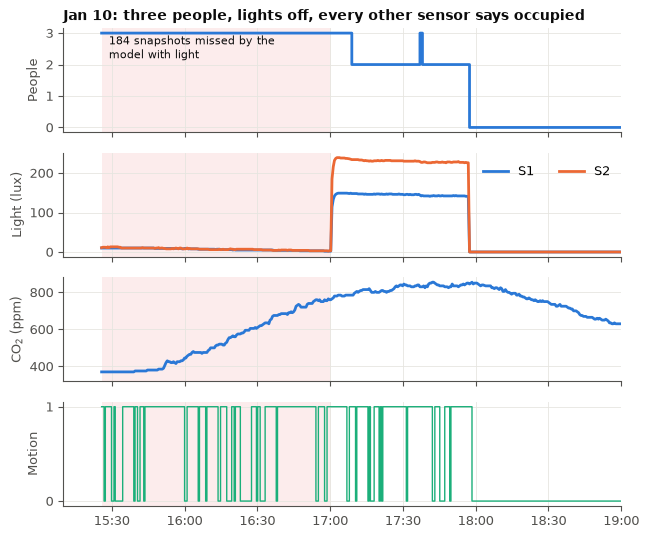

In [7]:
# Figure 1: the Jan 10 lights-off session
d = o[o.day == '2018-01-10'].copy(); d['pred'] = pred_light[:len(d)]
fig, ax = plt.subplots(4, 1, figsize=(7.2, 6.2), sharex=True)
ax[0].step(d.Datetime, d.Room_Occupancy_Count, where='post', color=C_BLUE); ax[0].set_ylabel('People'); ax[0].set_yticks([0, 1, 2, 3])
ax[1].plot(d.Datetime, d.S1_Light, color=C_BLUE, label='S1'); ax[1].plot(d.Datetime, d.S2_Light, color=C_ORANGE, label='S2'); ax[1].set_ylabel('Light (lux)'); ax[1].legend(frameon=False, loc='upper right', ncol=2)
ax[2].plot(d.Datetime, d.S5_CO2, color=C_BLUE); ax[2].set_ylabel('CO$_2$ (ppm)')
ax[3].step(d.Datetime, d[['S6_PIR', 'S7_PIR']].max(axis=1), where='post', color=C_AQUA, linewidth=1); ax[3].set_ylabel('Motion'); ax[3].set_yticks([0, 1])
for a in ax:
    a.axvspan(miss.Datetime.min(), miss.Datetime.max(), color=C_RED, alpha=0.10, lw=0)
    a.set_xlim(pd.Timestamp('2018-01-10 15:10'), pd.Timestamp('2018-01-10 19:00'))
ax[0].text(miss.Datetime.min() + pd.Timedelta('3min'), 2.2, '184 snapshots missed by the\nmodel with light', color=INK, fontsize=8)
ax[3].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].set_title('Jan 10: three people, lights off, every other sensor says occupied', loc='left')
fig.savefig(FIG + 'fig1_jan10_lights_off.png'); plt.show()

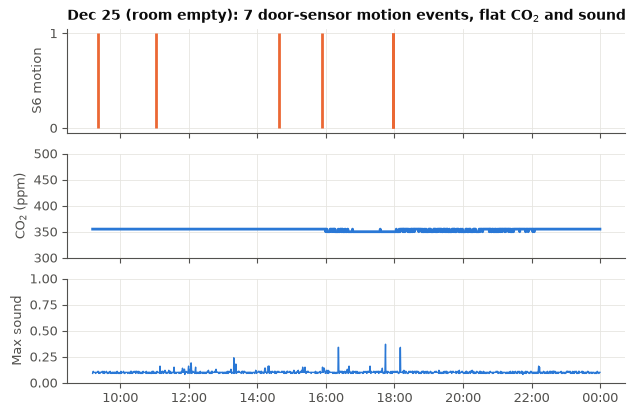

In [8]:
# Figure 2: motion firing on Christmas Day with nobody there
d = raw[(raw.day == '2017-12-25')]
fig, ax = plt.subplots(3, 1, figsize=(7.2, 4.6), sharex=True)
ax[0].vlines(d.Datetime[d.S6_PIR == 1], 0, 1, color=C_ORANGE, linewidth=2); ax[0].set_ylabel('S6 motion'); ax[0].set_yticks([0, 1])
ax[1].plot(d.Datetime, d.S5_CO2, color=C_BLUE); ax[1].set_ylabel('CO$_2$ (ppm)'); ax[1].set_ylim(300, 500)
ax[2].plot(d.Datetime, d[SOUND].max(axis=1), color=C_BLUE, linewidth=1); ax[2].set_ylabel('Max sound'); ax[2].set_ylim(0, 1)
ax[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax[0].set_title('Dec 25 (room empty): 7 door-sensor motion events, flat CO$_2$ and sound', loc='left')
fig.savefig(FIG + 'fig2_dec25_phantom_motion.png'); plt.show()

## C. Features
My original rolling features ran across the gaps in the recording (one of 24 hours and one of 15 days), so here I compute
every rolling window inside a continuous stretch of recording. New features I added:
- **counts** of motion firings, not just "any motion"
- rolling **sound** peak and mean
- CO2 change over 5 and 10 minutes
- CO2 above its trailing 2-hour minimum
- a capped log of time since motion
- temperature change over 10 minutes

All of them only look backwards, so they could run live.

In [9]:
def build_features(r):
    df = r.copy()
    seg = (df.Datetime.diff().dt.total_seconds().fillna(1e9) > 300).cumsum()
    by = lambda s, f: s.groupby(seg, group_keys=False).apply(f)
    df['S6_PIR_5min'] = by(df.S6_PIR, lambda s: s.rolling(10, min_periods=1).max())
    df['S7_PIR_5min'] = by(df.S7_PIR, lambda s: s.rolling(10, min_periods=1).max())
    df['PIR_any'] = df[['S6_PIR', 'S7_PIR']].max(axis=1)
    df['PIR_cnt_5min']  = by(df.PIR_any, lambda s: s.rolling(10, min_periods=1).sum())
    df['PIR_cnt_10min'] = by(df.PIR_any, lambda s: s.rolling(20, min_periods=1).sum())
    def tsm(s):
        g = (s == 1).cumsum(); c = g.groupby(g).cumcount().astype(float)
        c[g == 0] += 120            # no motion seen yet in this segment: assume a long silence
        return c
    df['time_since_motion'] = by(df.PIR_any, tsm)
    df['log_tsm'] = np.log1p(df.time_since_motion.clip(upper=240))
    loud = df[SOUND].max(axis=1)
    df['Sound_max_5min']  = by(loud, lambda s: s.rolling(10, min_periods=1).max())
    df['Sound_mean_5min'] = by(loud, lambda s: s.rolling(10, min_periods=1).mean())
    df['CO2_d5']  = by(df.S5_CO2, lambda s: s.diff(10)).fillna(0)
    df['CO2_d10'] = by(df.S5_CO2, lambda s: s.diff(20)).fillna(0)
    df['CO2_above_min2h'] = df.S5_CO2 - by(df.S5_CO2, lambda s: s.rolling(240, min_periods=1).min())
    df['Temp_d10'] = by(df[TEMP].mean(axis=1), lambda s: s.diff(20)).fillna(0)
    df['hour'] = df.Datetime.dt.hour + df.Datetime.dt.minute / 60
    return df

df = build_features(raw)
EXT = SOUND + ['Sound_max_5min', 'Sound_mean_5min', 'S5_CO2_Slope', 'CO2_d5', 'CO2_d10', 'CO2_above_min2h',
               'PIR_cnt_5min', 'PIR_cnt_10min', 'log_tsm', 'Temp_d10']
ORIG_L = TEMP + LIGHT + SOUND + ['S5_CO2', 'S5_CO2_Slope', 'S6_PIR_5min', 'S7_PIR_5min', 'time_since_motion']
RAW_NL = TEMP + SOUND + ['S5_CO2', 'S5_CO2_Slope', 'S6_PIR', 'S7_PIR']
DAYS = sorted(df.day.unique()); OCC_DAYS = ['2017-12-22', '2017-12-23', '2018-01-10']
df.groupby('occupied')[['PIR_cnt_10min', 'Sound_max_5min', 'CO2_above_min2h', 'log_tsm']].median()

,PIR_cnt_10min,Sound_max_5min,CO2_above_min2h,log_tsm
occupied,,,,
0,0.0,0.09,0.0,5.484797
1,12.0,2.13,185.0,0.000000


## D. Leave-one-day-out comparison
I hold out each of the 7 days in turn and train on the other 6.
That way every occupied day, including Jan 10, gets a turn as the test day, and every empty day gets checked for false alarms.
My original split only tested one occupied episode.

In [10]:
class Rule:
    '''A fixed if-then rule, wrapped so it can be evaluated like a model.'''
    def __init__(self, f): self.f = f
    def fit(self, X, y): return self
    def predict_proba(self, X): p = self.f(X).astype(float); return np.c_[1 - p, p]

def lr(): return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight='balanced'))
def lgbm(): return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, class_weight='balanced', verbose=-1, random_state=42)
rule_corroborated = lambda X: (X.PIR_cnt_5min >= 1) & ((X.CO2_above_min2h >= 15) | (X.Sound_max_5min > 0.3))

MODELS = {
 'Rule: motion in last 5 min':            (lambda: Rule(lambda X: X.PIR_cnt_5min >= 1), EXT),
 'Rule: motion + (CO2 or sound)':         (lambda: Rule(rule_corroborated), EXT),
 'LR original (unscaled)':                (lambda: LogisticRegression(max_iter=1000, class_weight='balanced'), ORIG_NL),
 'LR original + light':                   (lambda: LogisticRegression(max_iter=1000, class_weight='balanced'), ORIG_L),
 'LR scaled':                             (lr, ORIG_NL),
 'LR scaled, raw PIR (no engineering)':   (lr, RAW_NL),
 'LR scaled, extended features':          (lr, EXT),
 'RF original (1000 trees, unpruned)':    (lambda: RandomForestClassifier(1000, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_NL),
 'RF original + light':                   (lambda: RandomForestClassifier(500, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_L),
 'RF regularised (min leaf 20)':          (lambda: RandomForestClassifier(500, min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_NL),
 'RF regularised, extended features':     (lambda: RandomForestClassifier(500, min_samples_leaf=20, class_weight='balanced', random_state=42, n_jobs=-1), EXT),
 'LightGBM':                              (lgbm, ORIG_NL),
 'LightGBM, extended features':           (lgbm, EXT),
 'SVM (RBF, scaled)':                     (lambda: make_pipeline(StandardScaler(), SVC(class_weight='balanced', probability=True, random_state=0)), ORIG_NL),
 'kNN (k=15, scaled)':                    (lambda: make_pipeline(StandardScaler(), KNeighborsClassifier(15)), ORIG_NL),
 'LDA':                                   (lambda: LinearDiscriminantAnalysis(), ORIG_NL),
 'Decision tree (depth 3)':               (lambda: DecisionTreeClassifier(max_depth=3, class_weight='balanced', random_state=42), ORIG_NL),
}

def lodo(make, cols, data=df, days=DAYS):
    proba = pd.Series(np.nan, index=data.index)
    for d in days:
        tr, te = data[data.day != d], data[data.day == d]
        proba[te.index] = make().fit(tr[cols], tr.occupied).predict_proba(te[cols])[:, 1]
    return proba

OOF, rows = {}, []
for name, (make, cols) in MODELS.items():
    p = lodo(make, cols); OOF[name] = p; pred = (p >= 0.5).astype(int); y = df.occupied
    tp, fn = int(((pred == 1) & (y == 1)).sum()), int(((pred == 0) & (y == 1)).sum())
    fp = int(((pred == 1) & (y == 0)).sum())
    row = dict(model=name, recall=tp/(tp+fn), precision=tp/(tp+fp), FP=fp, FP_rate=fp/int((y == 0).sum()),
               F1=f1_score(y, pred), PR_AUC=average_precision_score(y, p), Brier=brier_score_loss(y, p),
               FP_Dec25=int(((pred == 1) & (y == 0) & (df.day == '2017-12-25')).sum()))
    for d in OCC_DAYS: row['recall_' + d] = recall_score(y[df.day == d], pred[df.day == d])
    rows.append(row)
cv = pd.DataFrame(rows).set_index('model').round(3)
RESULTS['lodo'] = cv.reset_index().to_dict('records'); cv

,recall,precision,FP,FP_rate,F1,PR_AUC,Brier,FP_Dec25,recall_2017-12-22,recall_2017-12-23,recall_2018-01-10
model,,,,,,,,,,,
Rule: motion in last 5 min,0.985,0.930,141,0.017,0.957,0.919,0.017,52,0.985,0.978,1.000
Rule: motion + (CO2 or sound),0.985,0.956,87,0.011,0.970,0.944,0.011,0,0.985,0.978,1.000
LR original (unscaled),0.991,0.812,435,0.053,0.893,0.970,0.030,345,0.989,0.990,1.000
LR original + light,0.898,0.914,160,0.019,0.906,0.953,0.032,148,0.989,1.000,0.374
LR scaled,0.932,0.912,171,0.021,0.922,0.952,0.030,76,0.848,0.994,1.000
"LR scaled, raw PIR (no engineering)",0.922,0.759,557,0.068,0.833,0.931,0.049,450,0.874,0.974,0.918
"LR scaled, extended features",0.975,0.913,177,0.022,0.943,0.974,0.018,122,0.972,0.969,1.000
"RF original (1000 trees, unpruned)",0.952,0.935,126,0.015,0.943,0.971,0.019,52,0.935,0.951,1.000
RF original + light,0.898,0.967,59,0.007,0.931,0.979,0.023,22,0.990,0.999,0.374


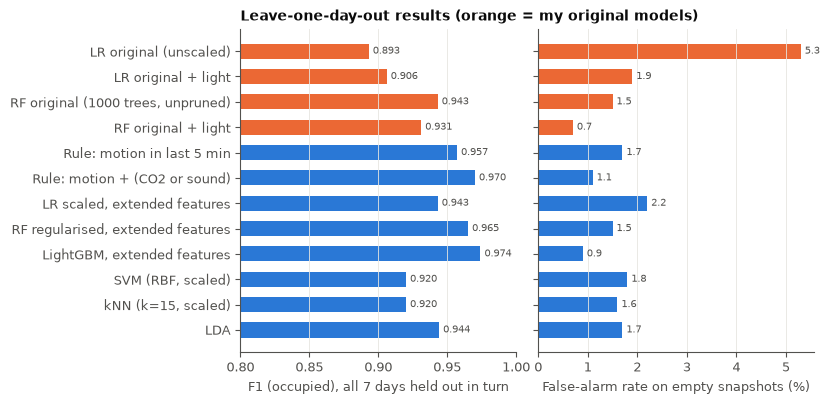

In [11]:
# Figure 3: F1 and false-alarm rate per model (two separate panels, same model order)
show = ['LR original (unscaled)', 'LR original + light', 'RF original (1000 trees, unpruned)', 'RF original + light',
        'Rule: motion in last 5 min', 'Rule: motion + (CO2 or sound)', 'LR scaled, extended features',
        'RF regularised, extended features', 'LightGBM, extended features', 'SVM (RBF, scaled)', 'kNN (k=15, scaled)', 'LDA']
t = cv.loc[show][::-1]; col = [C_ORANGE if ('original' in m) else C_BLUE for m in t.index]
fig, ax = plt.subplots(1, 2, figsize=(7.4, 4.2), sharey=True, gridspec_kw={'wspace': 0.08})
ax[0].barh(t.index, t.F1, color=col, height=0.6); ax[0].set_xlim(0.8, 1.0); ax[0].set_xlabel('F1 (occupied), all 7 days held out in turn')
ax[1].barh(t.index, 100 * t.FP_rate, color=col, height=0.6); ax[1].set_xlabel('False-alarm rate on empty snapshots (%)')
for i, (f, r) in enumerate(zip(t.F1, t.FP_rate)):
    ax[0].text(f + 0.003, i, f'{f:.3f}', va='center', fontsize=7, color=INK2); ax[1].text(100*r + 0.08, i, f'{100*r:.1f}', va='center', fontsize=7, color=INK2)
for a in ax: a.grid(axis='y', visible=False)
ax[0].set_title('Leave-one-day-out results (orange = my original models)', loc='left')
fig.savefig(FIG + 'fig3_lodo_comparison.png'); plt.show()

## E. Where the errors happen, and the release rule

In [12]:
trans = df.Datetime[df.occupied.diff().fillna(0) != 0].values
dist_min = np.abs(df.Datetime.values[:, None] - trans[None, :]).min(axis=1) / np.timedelta64(1, 'm')
for name in ['LR original (unscaled)', 'Rule: motion + (CO2 or sound)', 'LightGBM, extended features']:
    pred = OOF[name] >= 0.5
    fp = pred & (df.occupied == 0); fn = ~pred & (df.occupied == 1)
    print(f'{name:32s} false alarms within 10 min of an arrival/departure: {int((fp & (dist_min <= 10)).sum())}/{int(fp.sum())}; '
          f'misses within 10 min: {int((fn & (dist_min <= 10)).sum())}/{int(fn.sum())}')

LR original (unscaled)           false alarms within 10 min of an arrival/departure: 60/435; misses within 10 min: 3/17
Rule: motion + (CO2 or sound)    false alarms within 10 min of an arrival/departure: 54/87; misses within 10 min: 9/29
LightGBM, extended features      false alarms within 10 min of an arrival/departure: 40/71; misses within 10 min: 3/29


In [13]:
def release_flags(pred_occ, N):
    pe = (~pred_occ).astype(int)
    streak = (pe.groupby((pe == 0).cumsum()).cumcount() + 1) * pe
    return streak >= N

def simulate(name, N):
    false_rel, latency = 0, []
    for d in DAYS:
        idx = df.index[df.day == d]
        rel = release_flags(pd.Series(OOF[name][idx].values >= 0.5, index=idx), N)
        occ = df.occupied[idx].values
        false_rel += int((rel & (occ == 1)).sum())
        for t in idx[(occ == 1) & (np.r_[occ[1:], 0] == 0)]:          # each departure
            after = rel[idx[idx > t]]
            if after.any(): latency.append((df.Datetime[after.idxmax()] - df.Datetime[t]).total_seconds() / 60)
    return false_rel, latency

pol = []
for name in ['LR original (unscaled)', 'Rule: motion + (CO2 or sound)', 'LightGBM, extended features']:
    for N in [10, 20, 30]:
        fr, lat = simulate(name, N)
        pol.append(dict(model=name, N=N, minutes=N/2, false_release_snapshots=fr,
                        median_release_after_departure_min=round(float(np.median(lat)), 1),
                        max_release_after_departure_min=round(float(np.max(lat)), 1), departures=len(lat)))
pol = pd.DataFrame(pol); RESULTS['policy'] = pol.to_dict('records'); pol

,model,N,minutes,false_release_snapshots,median_release_after_departure_min,max_release_after_departure_min,departures
0,LR original (unscaled),10,5.0,0,11.2,12.8,5
1,LR original (unscaled),20,10.0,0,17.9,26.0,5
2,LR original (unscaled),30,15.0,0,23.0,31.1,5
3,Rule: motion + (CO2 or sound),10,5.0,0,10.7,12.2,5
4,Rule: motion + (CO2 or sound),20,10.0,0,15.8,28.1,5
5,Rule: motion + (CO2 or sound),30,15.0,0,20.9,33.2,5
6,"LightGBM, extended features",10,5.0,3,10.7,12.2,5
7,"LightGBM, extended features",20,10.0,3,16.3,17.4,5
8,"LightGBM, extended features",30,15.0,3,21.4,22.5,5


In [14]:
# where are LightGBM's 3 false-release snapshots?
name = 'LightGBM, extended features'; idx = df.index
rel = pd.concat([release_flags(pd.Series(OOF[name][df.index[df.day == d]].values >= 0.5, index=df.index[df.day == d]), 10) for d in DAYS])
df.loc[rel[rel & (df.occupied == 1)].index, ['Datetime', 'Room_Occupancy_Count', 'PIR_cnt_10min', 'CO2_above_min2h', 'Sound_max_5min']]

,Datetime,Room_Occupancy_Count,PIR_cnt_10min,CO2_above_min2h,Sound_max_5min
479,2017-12-22 15:25:24,1,1.0,0.0,1.29
480,2017-12-22 15:25:55,1,1.0,0.0,1.29
481,2017-12-22 15:26:25,1,1.0,0.0,1.29


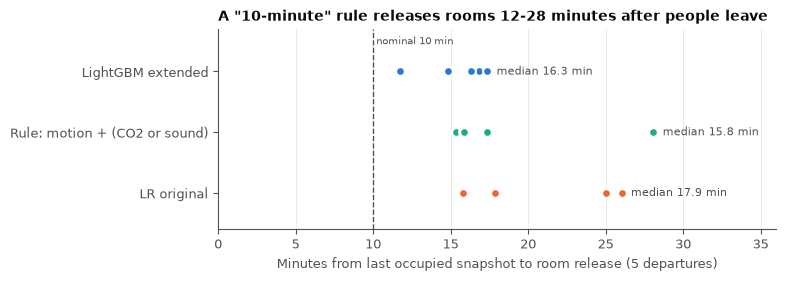

In [15]:
# Figure 5: how long after people leave the room actually gets released (N = 20, my '10 minutes')
fig, ax = plt.subplots(figsize=(7.2, 2.6))
for i, (name, c) in enumerate([('LR original (unscaled)', C_ORANGE), ('Rule: motion + (CO2 or sound)', C_AQUA), ('LightGBM, extended features', C_BLUE)]):
    lat = simulate(name, 20)[1]
    ax.scatter(lat, [i] * len(lat), s=40, color=c, edgecolor='white', linewidth=1.5, zorder=3)
    ax.text(max(lat) + 0.6, i, f'median {np.median(lat):.1f} min', va='center', fontsize=8, color=INK2)
ax.axvline(10, color=INK2, linestyle='--', linewidth=1); ax.text(10.2, 2.45, 'nominal 10 min', fontsize=7, color=INK2)
ax.set_yticks([0, 1, 2], ['LR original', 'Rule: motion + (CO2 or sound)', 'LightGBM extended']); ax.set_ylim(-0.6, 2.7); ax.set_xlim(0, 36)
ax.set_xlabel('Minutes from last occupied snapshot to room release (5 departures)'); ax.grid(axis='y', visible=False)
ax.set_title('A "10-minute" rule releases rooms 12-28 minutes after people leave', loc='left')
fig.savefig(FIG + 'fig5_release_latency.png'); plt.show()

## F. Stress tests
**A person sitting still:** in every occupied episode I set both motion sensors to 0 for a block of time starting
30 minutes in, rebuild the features and re-run leave-one-day-out on the occupied days. I had listed this case as
untested in my first analysis.

**Losing a sensor:** I remove one sensor group at a time from the best model.

In [16]:
def silence(r, minutes):
    r = r.copy(); ep = (r.occupied.diff() != 0).cumsum()
    for _, g in r[r.occupied == 1].groupby(ep):
        t0 = g.Datetime.iloc[0] + pd.Timedelta('30min')
        r.loc[g[(g.Datetime >= t0) & (g.Datetime < t0 + pd.Timedelta(minutes=minutes))].index, ['S6_PIR', 'S7_PIR']] = 0
    return r

STRESS = {'LR original (unscaled)': MODELS['LR original (unscaled)'], 'Rule: motion + (CO2 or sound)': MODELS['Rule: motion + (CO2 or sound)'],
          'LightGBM, extended features': MODELS['LightGBM, extended features']}
st = []
for minutes in [0, 10, 20, 30, 40]:
    dS = build_features(silence(raw, minutes))
    for name, (make, cols) in STRESS.items():
        p = lodo(make, cols, dS, OCC_DAYS); m = dS.day.isin(OCC_DAYS)
        pred = pd.Series(p[m] >= 0.5, index=dS.index[m])
        fr = sum(int((release_flags(pred[dS.day[m] == d], 20) & (dS.occupied[m][dS.day[m] == d] == 1)).sum()) for d in OCC_DAYS)
        st.append(dict(silence_min=minutes, model=name, recall=round(recall_score(dS.occupied[m], pred), 3), false_release_snapshots_N20=fr))
st = pd.DataFrame(st); RESULTS['stillness'] = st.to_dict('records'); st.pivot(index='silence_min', columns='model', values=['recall', 'false_release_snapshots_N20'])

recall                                                           false_release_snapshots_N20                                                          
model       LR original (unscaled) LightGBM, extended features Rule: motion + (CO2 or sound)      LR original (unscaled) LightGBM, extended features Rule: motion + (CO2 or sound)
silence_min                                                                                                                                                                       
0                            0.991                       0.985                         0.985                         0.0                         3.0                           0.0
10                           0.988                       0.968                         0.948                         0.0                         1.0                           5.0
20                           0.988                       0.983                         0.904                         0.0                         2.0                          68.0
30                           0.988                       0.980                         0.851                         0.0                         2.0                         169.0
40                           0.985                       0.977                         0.801                         0.0                         3.0                         265.0

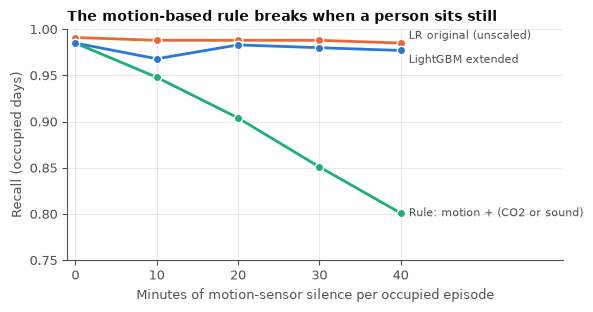

In [17]:
fig, ax = plt.subplots(figsize=(6.4, 3.0))
for name, c in [('LR original (unscaled)', C_ORANGE), ('Rule: motion + (CO2 or sound)', C_AQUA), ('LightGBM, extended features', C_BLUE)]:
    s = st[st.model == name]; ax.plot(s.silence_min, s.recall, color=c, marker='o', markersize=6, markeredgecolor='white')
    dy = {'LR original (unscaled)': 0.008, 'LightGBM, extended features': -0.010}.get(name, 0)
    ax.text(41, s.recall.iloc[-1] + dy, name.replace(', extended features', ' extended'), va='center', fontsize=8, color=INK2)
ax.set_xlabel('Minutes of motion-sensor silence per occupied episode'); ax.set_ylabel('Recall (occupied days)')
ax.set_xlim(-1, 60); ax.set_ylim(0.75, 1.0); ax.set_xticks([0, 10, 20, 30, 40])
ax.set_title('The motion-based rule breaks when a person sits still', loc='left')
fig.savefig(FIG + 'fig4_stillness.png'); plt.show()

In [18]:
abl = []
drops = {'none': [], 'sound': [c for c in EXT if 'Sound' in c], 'motion (PIR)': ['PIR_cnt_5min', 'PIR_cnt_10min', 'log_tsm'],
         'CO2': ['S5_CO2_Slope', 'CO2_d5', 'CO2_d10', 'CO2_above_min2h'], 'temperature': ['Temp_d10']}
for g, drop in drops.items():
    cols = [c for c in EXT if c not in drop]; pred = lodo(lgbm, cols) >= 0.5; y = df.occupied
    abl.append(dict(removed=g, recall=recall_score(y, pred), F1=f1_score(y, pred), FP=int((pred & (y == 0)).sum()),
                    FP_Dec25=int((pred & (y == 0) & (df.day == '2017-12-25')).sum())))
abl = pd.DataFrame(abl).round(3); RESULTS['ablation'] = abl.to_dict('records'); abl

,removed,recall,F1,FP,FP_Dec25
0,none,0.985,0.974,71,6
1,sound,0.974,0.951,142,83
2,motion (PIR),0.982,0.972,73,5
3,CO2,0.988,0.976,69,9
4,temperature,0.978,0.971,71,10


## G. What the models rely on
Permutation importance on my original split: how much F1 on Jan 10-11 drops when I shuffle one feature.

In [19]:
tr, te = df[df.Datetime < '2018-01-10'], df[df.Datetime >= '2018-01-10']
imp = {}
for name, make, cols in [('RF original', lambda: RandomForestClassifier(1000, class_weight='balanced', random_state=42, n_jobs=-1), ORIG_NL),
                         ('LightGBM extended', lgbm, EXT)]:
    m = make().fit(tr[cols], tr.occupied)
    pi = permutation_importance(m, te[cols], te.occupied, scoring='f1', n_repeats=10, random_state=0)
    imp[name] = pd.Series(pi.importances_mean, index=cols).sort_values(ascending=False)
    print(name, '| permutation (F1 drop):', imp[name].head(5).round(3).to_dict())
    print('   built-in importance top 5:', pd.Series(m.feature_importances_, index=cols).sort_values(ascending=False).head(5).index.tolist())
RESULTS['perm_importance'] = {k: v.head(6).round(3).to_dict() for k, v in imp.items()}
m = lgb.LGBMClassifier(verbose=-1, class_weight='balanced').fit(tr[ORIG_NL + ['hour']], tr.occupied)
print('rank of hour-of-day among features if it were allowed:',
      list(pd.Series(m.feature_importances_, index=ORIG_NL + ['hour']).sort_values(ascending=False).index).index('hour') + 1)

RF original | permutation (F1 drop): {'S5_CO2': 0.315, 'time_since_motion': 0.049, 'S2_Temp': 0.001, 'S6_PIR_5min': 0.001, 'S5_CO2_Slope': 0.0}
   built-in importance top 5: ['time_since_motion', 'S6_PIR_5min', 'S1_Sound', 'S5_CO2_Slope', 'S2_Sound']


LightGBM extended | permutation (F1 drop): {'Sound_max_5min': 0.625, 'Sound_mean_5min': 0.021, 'PIR_cnt_10min': 0.016, 'log_tsm': 0.013, 'S1_Sound': 0.003}
   built-in importance top 5: ['Sound_max_5min', 'S5_CO2_Slope', 'CO2_above_min2h', 'Sound_mean_5min', 'PIR_cnt_10min']
rank of hour-of-day among features if it were allowed: 3


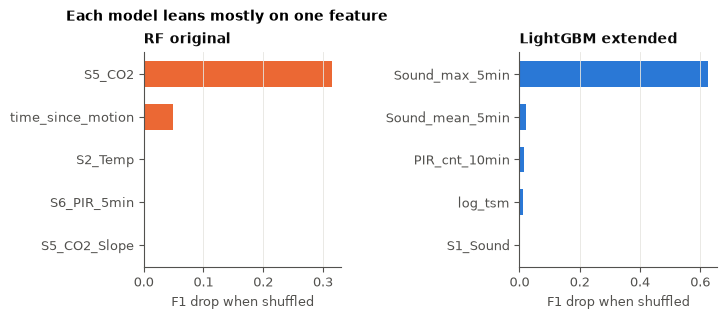

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(7.4, 2.8), gridspec_kw={'wspace': 0.9})
for a, (name, c) in zip(ax, [('RF original', C_ORANGE), ('LightGBM extended', C_BLUE)]):
    s = imp[name].head(5)[::-1]; a.barh(s.index, s.values, color=c, height=0.6); a.set_title(name, loc='left'); a.grid(axis='y', visible=False)
    a.set_xlabel('F1 drop when shuffled')
fig.suptitle('Each model leans mostly on one feature', x=0.02, ha='left', fontweight='bold', fontsize=10, y=1.03)
fig.savefig(FIG + 'fig6_permutation_importance.png'); plt.show()

## H. Head-count estimation (0-3 people)
This is what the dataset was built for, and I skipped it in my first analysis. I evaluate it by holding out each occupied day and compare with a random 75/25 split.

In [21]:
y = df.Room_Occupancy_Count; occ = df.day.isin(OCC_DAYS); cnt = []
def lgbm_mc(): return lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=15, class_weight='balanced', verbose=-1, random_state=42)
def rf_mc(): return RandomForestClassifier(500, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
for fs_name, cols in [('without light', EXT + TEMP + ['S5_CO2']), ('with light', EXT + TEMP + ['S5_CO2'] + LIGHT)]:
    for mname, make in [('LightGBM', lgbm_mc), ('Random forest', rf_mc)]:
        pred = pd.Series(0, index=df.index)
        for d in OCC_DAYS:
            a, b = df[df.day != d], df[df.day == d]; pred[b.index] = make().fit(a[cols], y[a.index]).predict(b[cols])
        cnt.append(dict(features=fs_name, model=mname, evaluation='leave-one-day-out', accuracy=accuracy_score(y[occ], pred[occ]), macro_F1=f1_score(y[occ], pred[occ], average='macro')))
        if (fs_name, mname) == ('with light', 'Random forest'): cm_count = confusion_matrix(y[occ], pred[occ])
cols = EXT + TEMP + ['S5_CO2'] + LIGHT
Xa, Xb, ya, yb = train_test_split(df[cols], y, test_size=0.25, random_state=0, stratify=y)
pr = rf_mc().fit(Xa, ya).predict(Xb)
cnt.append(dict(features='with light', model='Random forest', evaluation='random 75/25 split', accuracy=accuracy_score(yb, pr), macro_F1=f1_score(yb, pr, average='macro')))
Xa, Xb, ya, yb = train_test_split(df[ORIG_NL], df.occupied, test_size=0.25, random_state=0, stratify=df.occupied)
pr = RandomForestClassifier(1000, class_weight='balanced', random_state=42, n_jobs=-1).fit(Xa, ya).predict(Xb)
print('binary RF original features, random split: F1 =', round(f1_score(yb, pr), 4), '(vs leave-one-day-out', cv.loc['RF original (1000 trees, unpruned)', 'F1'], ')')
cnt = pd.DataFrame(cnt).round(3); RESULTS['headcount'] = cnt.to_dict('records'); cnt

binary RF original features, random split: F1 = 0.9927 (vs leave-one-day-out 0.943 )


,features,model,evaluation,accuracy,macro_F1
0,without light,LightGBM,leave-one-day-out,0.771,0.554
1,without light,Random forest,leave-one-day-out,0.773,0.561
2,with light,LightGBM,leave-one-day-out,0.820,0.673
3,with light,Random forest,leave-one-day-out,0.864,0.771
4,with light,Random forest,random 75/25 split,0.998,0.993


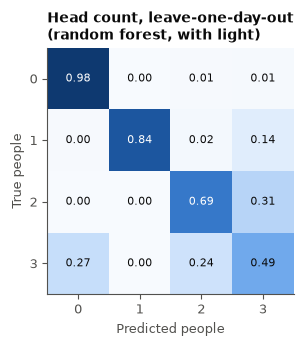

In [22]:
fig, ax = plt.subplots(figsize=(3.6, 3.2))
norm = cm_count / cm_count.sum(axis=1, keepdims=True)
ax.imshow(norm, cmap=plt.matplotlib.colors.LinearSegmentedColormap.from_list('b', ['#f7fafe', '#cde2fb', '#6da7ec', '#256abf', '#0d366b']), vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{norm[i, j]:.2f}', ha='center', va='center', fontsize=8, color='white' if norm[i, j] > 0.55 else INK)
ax.set_xticks(range(4)); ax.set_yticks(range(4)); ax.set_xlabel('Predicted people'); ax.set_ylabel('True people'); ax.grid(False)
ax.set_title('Head count, leave-one-day-out\n(random forest, with light)', loc='left')
fig.savefig(FIG + 'fig7_headcount_confusion.png'); plt.show()

In [23]:
with open('reanalysis_results.json', 'w') as f:
    json.dump(RESULTS, f, indent=2, default=lambda x: x.item() if hasattr(x, 'item') else str(x))
print('saved reanalysis_results.json')

saved reanalysis_results.json
